
--- Investment Advisor Menu ---
1. Add New User
2. Search User
3. Exit


Enter choice:  Diya


Invalid choice. Try again.

--- Investment Advisor Menu ---
1. Add New User
2. Search User
3. Exit


Enter choice:  1
Enter your name:  Diya
Enter your age:  20
Enter investment goal (short/medium/long):  medium
Enter monthly investment amount:  2000
Enter number of years:  2
Enter target amount:  100000


✅ User added successfully!

--- Personalized Advice ---
Consider SIPs and balanced mutual funds.

--- Investment Options Comparison ---
       Option  Expected Return (%)   Risk
          SIP                   12 Medium
       Stocks                   15   High
         Gold                    7 Medium
Fixed Deposit                    6    Low

--- Growth Graph ---


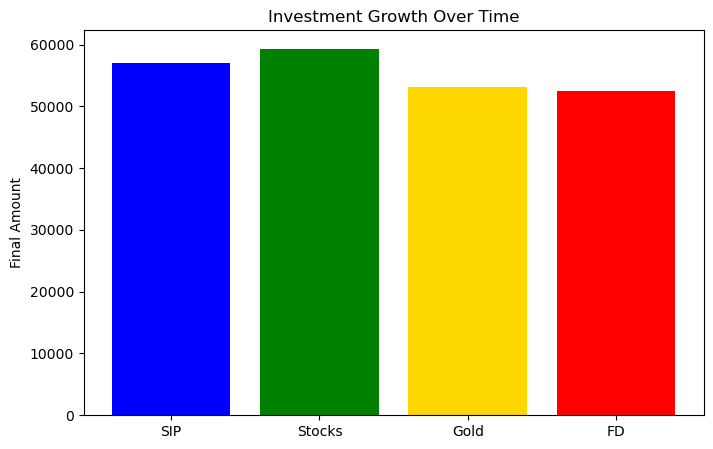


--- Risk Factor Chart ---


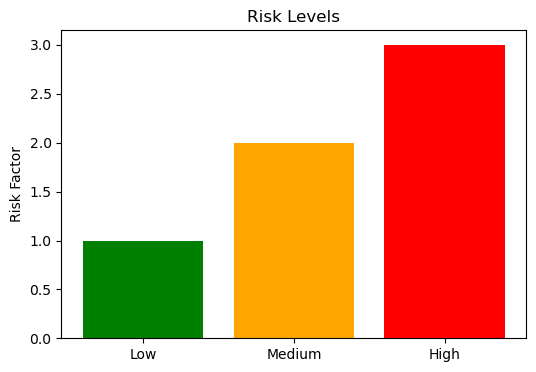


--- Investment Advisor Menu ---
1. Add New User
2. Search User
3. Exit


In [ ]:
import json
import os
import matplotlib.pyplot as plt
import pandas as pd

USER_FILE = "users.json"

# ------------------ Data Handling ------------------

def load_users():
    if os.path.exists(USER_FILE):
        with open(USER_FILE, "r") as f:
            return json.load(f)
    return []

def save_users(users):
    with open(USER_FILE, "w") as f:
        json.dump(users, f, indent=4)

# ------------------ User Functions ------------------

def add_user():
    name = input("Enter your name: ")
    age = int(input("Enter your age: "))
    goal = input("Enter investment goal (short/medium/long): ").lower()
    monthly_investment = float(input("Enter monthly investment amount: "))
    years = int(input("Enter number of years: "))
    target_amount = float(input("Enter target amount: "))

    user = {
        "name": name,
        "age": age,
        "goal": goal,
        "monthly_investment": monthly_investment,
        "years": years,
        "target_amount": target_amount
    }

    users = load_users()
    users.append(user)
    save_users(users)
    print("✅ User added successfully!")

    give_advice(user)
    show_comparison_table()
    show_growth_graph(user)
    show_risk_chart()

def search_user():
    name = input("Enter name to search: ")
    users = load_users()
    for user in users:
        if user["name"].lower() == name.lower():
            print("User found:", user)
            give_advice(user)
            show_comparison_table()
            show_growth_graph(user)
            show_risk_chart()
            return
    print("❌ User not found.")

# ------------------ Advice ------------------

def give_advice(user):
    print("\n--- Personalized Advice ---")
    if user["goal"] == "short":
        print("Focus on Fixed Deposits or Gold for stability.")
    elif user["goal"] == "medium":
        print("Consider SIPs and balanced mutual funds.")
    elif user["goal"] == "long":
        print("Stocks and SIPs can help achieve higher growth.")
    else:
        print("Goal not recognized. Please choose short-term, medium-term, or long-term.")

# ------------------ Comparison Table ------------------

def show_comparison_table():
    print("\n--- Investment Options Comparison ---")
    data = {
        "Option": ["SIP", "Stocks", "Gold", "Fixed Deposit"],
        "Expected Return (%)": [12, 15, 7, 6],
        "Risk": ["Medium", "High", "Medium", "Low"]
    }
    df = pd.DataFrame(data)
    print(df.to_string(index=False))

# ------------------ Growth Graph ------------------

def show_growth_graph(user):
    print("\n--- Growth Graph ---")
    years = user["years"]
    monthly = user["monthly_investment"]

    rates = {"SIP": 0.12, "Stocks": 0.15, "Gold": 0.07, "FD": 0.06}
    growth = {}

    for option, rate in rates.items():
        amount = 0
        for y in range(years):
            amount = (amount + monthly * 12) * (1 + rate)
        growth[option] = amount

    plt.figure(figsize=(8, 5))
    plt.bar(growth.keys(), growth.values(), color=["blue", "green", "gold", "red"])
    plt.title("Investment Growth Over Time")
    plt.ylabel("Final Amount")
    plt.show()

# ------------------ Risk Chart ------------------

def show_risk_chart():
    print("\n--- Risk Factor Chart ---")
    risks = {"Low": 1, "Medium": 2, "High": 3}
    plt.figure(figsize=(6, 4))
    plt.bar(risks.keys(), risks.values(), color=["green", "orange", "red"])
    plt.title("Risk Levels")
    plt.ylabel("Risk Factor")
    plt.show()

# ------------------ Menu ------------------

def menu():
    while True:
        print("\n--- Investment Advisor Menu ---")
        print("1. Add New User")
        print("2. Search User")
        print("3. Exit")
        choice = input("Enter choice: ")

        if choice == "1":
            add_user()
        elif choice == "2":
            search_user()
        elif choice == "3":
            print("👋 Exiting program. Goodbye!")
            break
        else:
            print("Invalid choice. Try again.")

if __name__ == "__main__":
    menu()